<a href="https://colab.research.google.com/github/Valeriy1990/Else/blob/main/19_3_%D0%97%D0%BD%D0%B0%D0%BA%D0%BE%D0%BC%D1%81%D1%82%D0%B2%D0%BE_%D1%81_KerasCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

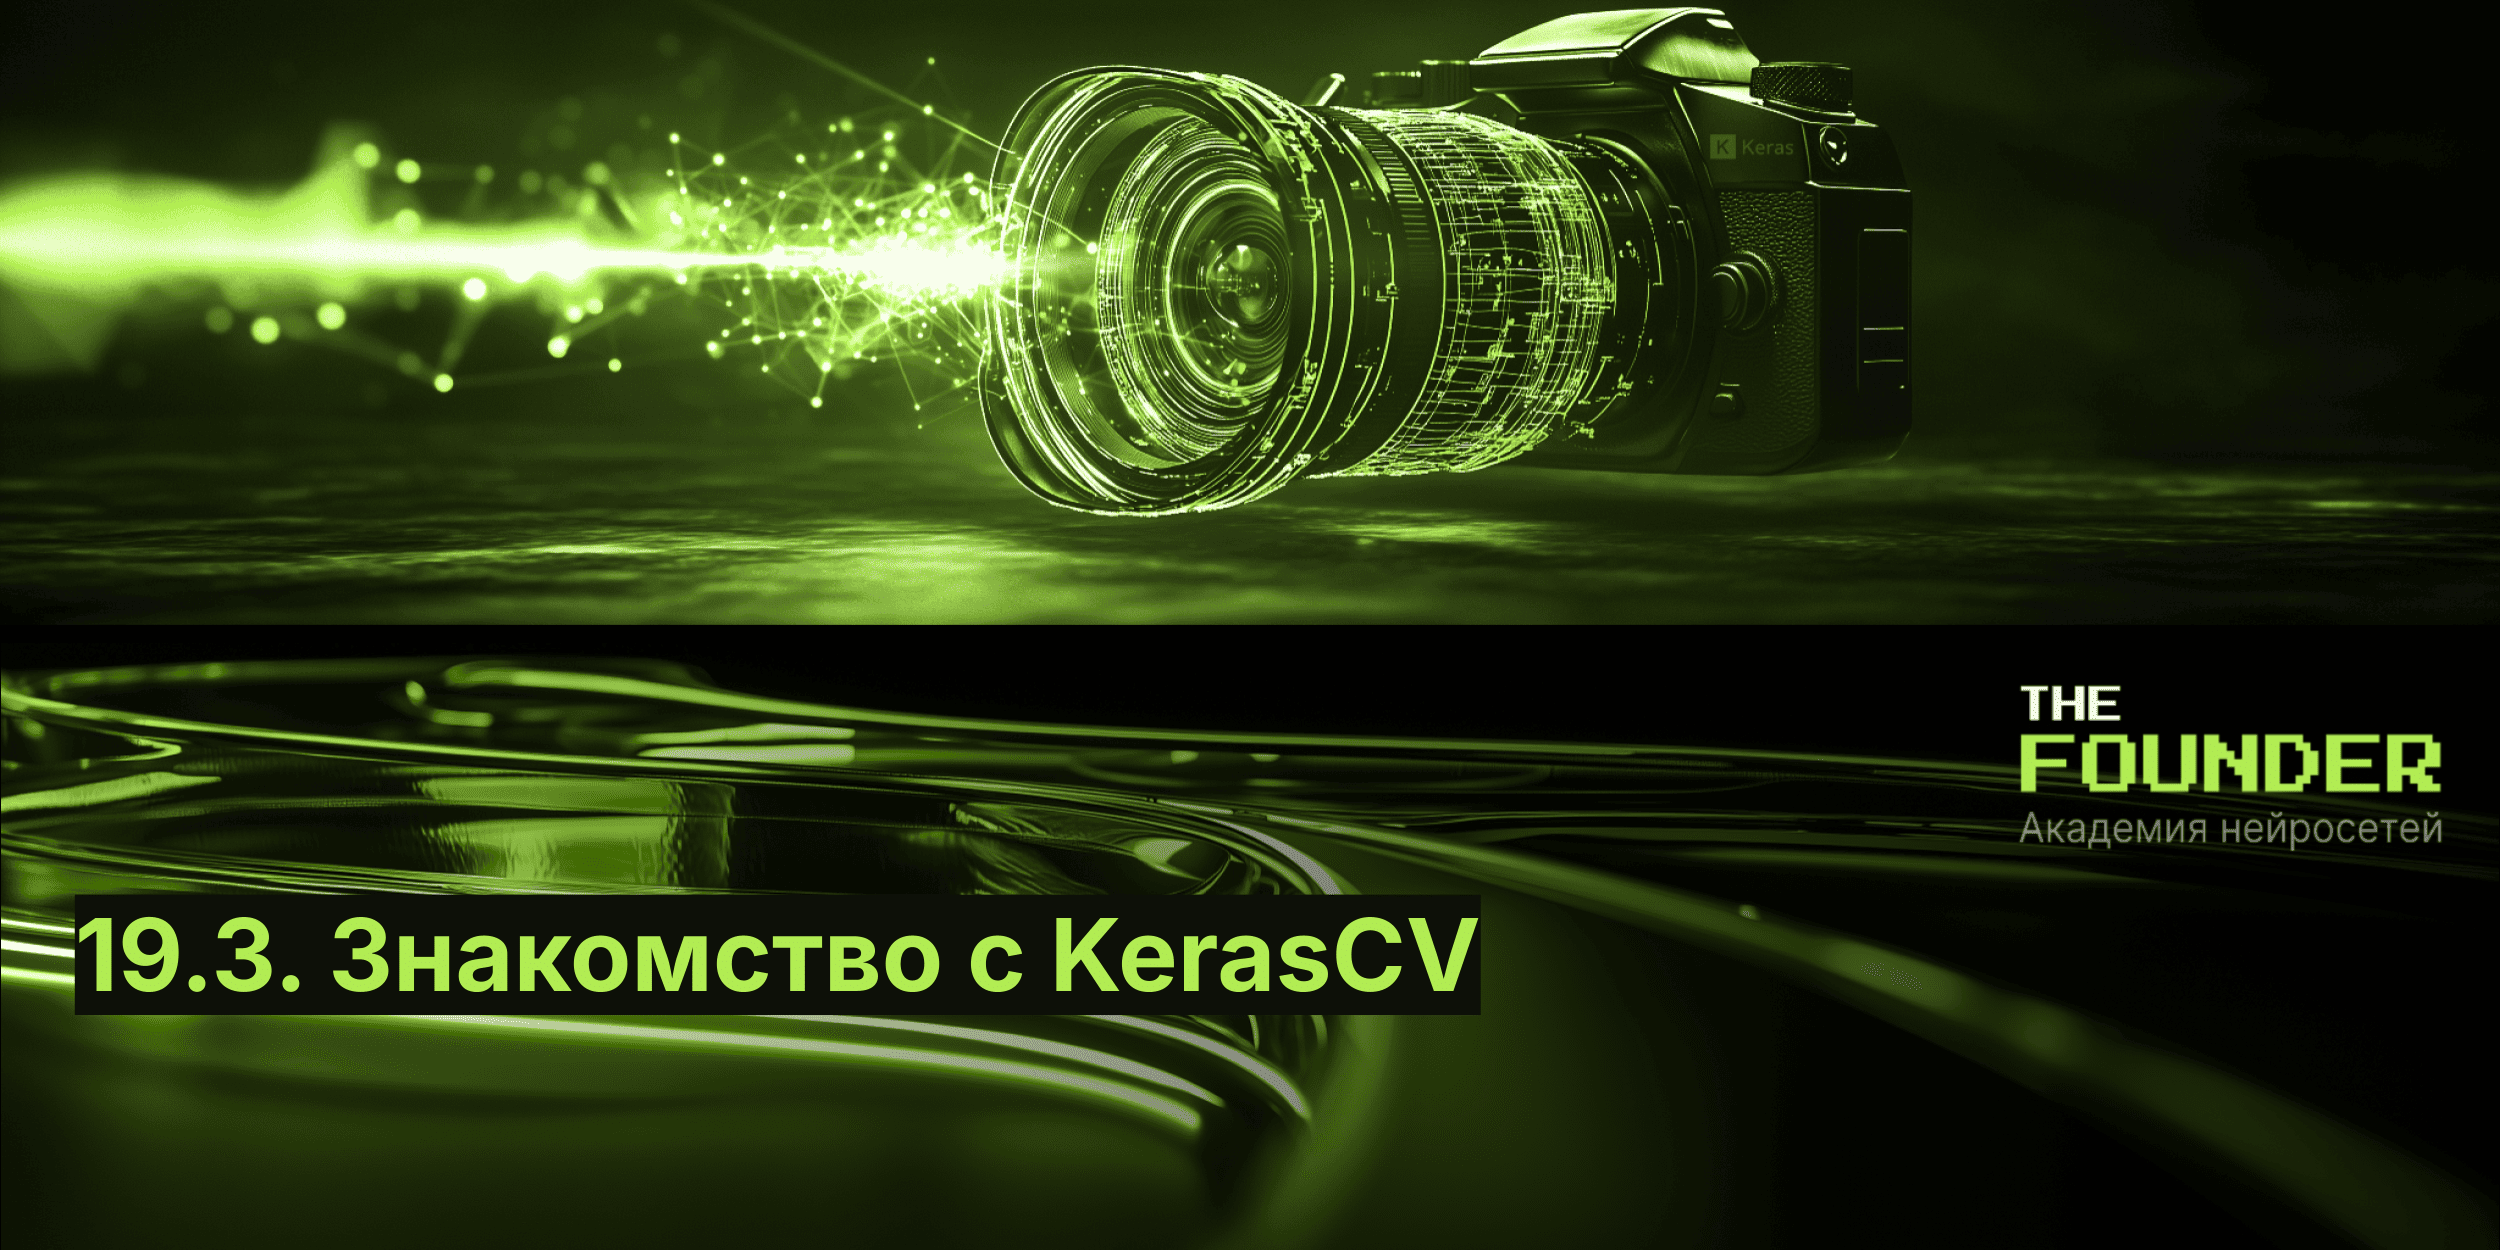

**Навигация по уроку**

1. [Keras v3. Современные подходы к CV (компьютерное зрение)](https://colab.research.google.com/drive/16ks3VjO38c7N4kXUsrdzUbunJOxRu3Fq)
2. [Перенос обучения в Keras 3.0](https://colab.research.google.com/drive/1x2qd4MvG3ODgNrE2uqxRAZB70dGgdGft)
3. Знакомство с KerasCV
4. [Домашняя работа](https://colab.research.google.com/drive/1ElbaB78l4c9BbIfHIgBMAzzr0-pBq4QO)

В данном уроке мы начнем знакомиться с библиотекой KerasCV. И покажем, что в KerasCV встроен свой собственный Stable Diffusion. Мы не будем создавать архитектуру StableDiffusion с нуля, и изучать сложную математику, мы лишь рассмотрим принципы, которые лежат в основе модели, но и конечно же, немного порисуем.

StableDiffusion — это мощная модель генерации изображений по текстовым описаниям с открытым исходным кодом. Мы уже знакомились с ней в первом уроке, теперь наша цель - рассмотреть ее реализация в KerasCV. Вообще существует множество решений StableDiffusion с открытым кодом для генерации изображений по описаниям, но KerasCV выделяется из них рядом преимуществ, в том числе **компилляцией XLA** и поддержкой **смешанной точности**. Вместе они позволяют достичь очень высокой скорости генерации по сравнению с конкурентами.

> **Смешанная точность** — это использование 16-битных и 32-битных типов данных с плавающей запятой в модели во время обучения, чтобы она работала быстрее и использовала меньше памяти. Сохраняя определенные части модели в 32-битных типах для числовой стабильности, модель будет иметь меньшее время шага и одинаково хорошо обучаться с точки зрения показателей оценки, таких как точность. Графические процессоры выполняют операции в float16 быстрее, чем в float32. API смешанной точности Keras позволяет использовать сочетание float16  с float32, чтобы получить преимущества производительности от float16 и преимущества числовой стабильности от float32.

> **XLA (ускоренная линейная алгебра)** — это компилятор с открытым исходным кодом для машинного обучения. Компилятор XLA берет модели из популярных платформ, таких как PyTorch, TensorFlow и JAX, и оптимизирует их для высокопроизводительного выполнения на различных аппаратных платформах, включая графические процессоры, центральные процессоры и ускорители машинного обучения.
В рамках проекта OpenXLA XLA создается совместно ведущими в отрасли компаниями по производству оборудования и программного обеспечения для машинного обучения, включая Alibaba, Amazon Web Services, AMD, Apple, Arm, Google, Intel, Meta и NVIDIA.

## Введение в KerasCV

Как утверждают сами разработчики Keras, модули KerasCV (компьютерное зрение) и KerasNLP (языковые модели) были вынесены в отдельные API с целью ускорить процесс разработки, собрать в отдельные модули лучшие модели, с лучшими весами и параметрами по умолчанию. Такие модули называют "горизонтальным дополнением" к Keras, т.е. они полностью совместимы и могут использоваться в Keras. Единственное отличие от "родных" методов Keras, что специализированные слои или модели берутся из другого пространства имен.

Так например, KerasCV содержит дополнительных 27 слоев для компьютерного зрения. Среди них 18 слоев для аугментации, 4 слоя для предобработки данных, и 5 слоев для регуляризации.

Что касается моделей, то KerasCV содержит сквозные реализации популярных архитектур моделей. Эти модели могут быть созданы тремя способами:
* с помощью конструктора `from_preset()`, который создает экземпляр объекта с предварительно обученной конфигурацией и весами:
```python
model = keras_cv.models.RetinaNet.from_preset(
    "resnet50_v2_imagenet", # preset (пресет) - предустановленная модель
    num_classes=20, # число классов для классификации
    bounding_box_format="xywh", # формат ограничивающих рамок входного набора данных для задач детекции объектов
)
```
* с помощью конфигурации, определенной пользователем. Для этого просто передайте желаемые параметры конфигурации конструктору модели.
```python
backbone = keras_cv.models.ResNetBackbone(
    stackwise_filters=[64, 128, 256, 512], # количество фильтров для каждого стека в модели
    stackwise_blocks=[2, 2, 2, 2], # количество блоков для каждого стека в модели
    stackwise_strides=[1, 2, 2, 2],  # шаг свертки для каждого стека в модели
    include_rescaling=False, # следует ли изменять масштаб входных данных
)
model = keras_cv.models.RetinaNet(
    backbone=backbone, # архитектура из конструктора
    num_classes=20, # число классов для классификации
    bounding_box_format="xywh", # формат ограничивающих рамок входного набора данных для задач детекции объектов
)
```
>Здесь в названии конструктора и параметре модели встречается слово `backbone`, которое правильно воспринимать как архитектура, костяк модели. Предопределенная модель, хоть и содержит определенную структуру, но через конструктор можно определить число фильтров, повторяющих структурных блоков, шаги свертки, то есть те "свободные" параметры модели, которые доступны для оптимизации!

* вызовом модели с параметрами, но без конструктора (скорее как исключение, для отдельных крупных моделей):
```python
keras_cv.models.StableDiffusion(img_width=512, img_height=512)
```

Таким образом KerasCV - это библиотека дополнений к Keras, содержащая самые популярные предобученные модели для задач компьютерного зрения, таких как:
* StableDiffusion
* RetinaNet
* ResNet
* YOLO
* MobileNet
* EfficientNet
* и другие модели.

Задачи компьютерного зрения - это не только классификация объектов, но также и детектирование и сегментация объектов.
Поэтому в рамках курса мы еще не раз вернемся к библиотеке KerasCV, по мере накопления знаний, и будет знакомится с ее возможностями.


## Перейдем к StableDiffusion

### Загрузка и импорт необходимых библиотек

Обновим версию keras-cv:

In [ ]:
!pip install --upgrade keras-cv

Импортируем необходимые модули:

In [ ]:
import time
import keras_cv
from tensorflow import keras
import matplotlib.pyplot as plt

Ниже ячейка решает проблему зависимостей keras-cv и tensorflow, пока разработчики не внесут правки в официальный релиз библиотек. Хороший разработчик должен быть всегда готов к проблемам в зависимостях и находить пути их решения. В код ячейки вникать не надо. Это временное решение. Кому интересно, то на проблему заведена задача в GitHub разработчика (https://github.com/keras-team/keras-io/issues/1982). Как только она перейдет в статус Merged,  то можно будет ячейку удалить.

In [ ]:
def fix_stable_diffusion():
    import keras_cv.src.models.stable_diffusion.text_encoder as text_encoder

    # Исправленная версия для CLIPAttention
    def fixed_clip_attention_call(self, inputs, attention_mask=None):
        batch_size, sequence_length = tf.shape(inputs)[0], tf.shape(inputs)[1]

        mixed_query_layer = self.q_proj(inputs)
        mixed_key_layer = self.k_proj(inputs)
        mixed_value_layer = self.v_proj(inputs)

        query_layer = tf.reshape(mixed_query_layer, [batch_size, sequence_length, self.num_heads, self.head_dim])
        query_layer = tf.transpose(query_layer, [0, 2, 1, 3])  # [batch, heads, seq, depth]

        key_layer = tf.reshape(mixed_key_layer, [batch_size, sequence_length, self.num_heads, self.head_dim])
        key_layer = tf.transpose(key_layer, [0, 2, 1, 3])  # [batch, heads, seq, depth]

        value_layer = tf.reshape(mixed_value_layer, [batch_size, sequence_length, self.num_heads, self.head_dim])
        value_layer = tf.transpose(value_layer, [0, 2, 1, 3])  # [batch, heads, seq, depth]

        scale = tf.cast(
            1.0 / tf.math.sqrt(tf.cast(self.head_dim, mixed_query_layer.dtype)),
            mixed_query_layer.dtype
        )
        attention_scores = tf.matmul(query_layer, key_layer, transpose_b=True) * scale

        if attention_mask is not None:
            attention_scores = attention_scores + attention_mask

        if getattr(self, "causal", False):
            # Создаем числовую причинную маску
            causal_mask = tf.ones((1, 1, sequence_length, sequence_length), dtype=attention_scores.dtype)
            causal_mask = tf.linalg.band_part(causal_mask, -1, 0)  # Нижняя треугольная части
            causal_mask = 1.0 - causal_mask  # Инвертируем для верхней треугольной части
            causal_mask = causal_mask * -1e9  # Большое отрицательное число для маскирования
            attention_scores = attention_scores + causal_mask

        attention_probs = tf.nn.softmax(attention_scores, axis=-1)
        context_layer = tf.matmul(attention_probs, value_layer)

        context_layer = tf.transpose(context_layer, [0, 2, 1, 3])  # [batch, seq, heads, depth]
        context_layer = tf.reshape(context_layer, [batch_size, sequence_length, self.embed_dim])

        outputs = self.out_proj(context_layer)
        return outputs

    # Заменяем метод call класса CLIPAttention
    text_encoder.CLIPAttention.call = fixed_clip_attention_call

    # Теперь проверяем, какие атрибуты действительно есть у CLIPEncoderLayer
    import inspect

    # Исправленная версия для CLIPEncoderLayer
    def fixed_clip_encoder_call(self, inputs):
        residual = inputs
        x = self.layer_norm1(inputs)
        x = self.clip_attn(x)
        x = residual + x

        residual = x
        x = self.layer_norm2(x)

        # Проверяем, какие атрибуты действительно используются
        # В оригинале, скорее всего, вместо mlp есть другой атрибут
        if hasattr(self, "mlp"):
            x = self.mlp(x)
        elif hasattr(self, "fc1"):
            # Типичная реализация MLP в трансформерах: fc1 -> активация -> fc2
            x = self.fc1(x)
            x = self.activation(x)
            x = self.fc2(x)
        elif hasattr(self, "ffn"):
            # Еще один вариант имени: ffn (feed-forward network)
            x = self.ffn(x)
        elif hasattr(self, "feed_forward"):
            x = self.feed_forward(x)
        # Добавьте больше вариантов по необходимости

        x = residual + x
        return x

    # Заменяем метод call класса CLIPEncoderLayer
    text_encoder.CLIPEncoderLayer.call = fixed_clip_encoder_call

    # Для диагностики выведем реальные атрибуты
    print("Доступные атрибуты CLIPEncoderLayer:", dir(text_encoder.CLIPEncoderLayer))

# Применяем патч
fix_stable_diffusion()

Доступные атрибуты CLIPEncoderLayer: ['__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_add_trackable_child', '_add_variable_with_custom_getter', '_api_export_path', '_api_export_symbol_id', '_assert_input_compatibility', '_build_by_run_for_kwargs', '_build_by_run_for_single_pos_arg', '_check_quantize_args', '_check_super_called', '_checkpoint_adapter', '_checkpoint_dependencies', '_clear_losses', '_copy_trackable_to_cpu', '_default_save_signature', '_deferred_dependencies', '_delete_tracking', '_deserialization_dependencies', '_deserialize_from_proto', '_export_to_saved_model_graph', '_flatten_layers', '_float8_call', '_gather_saveables_for_checkpoint', '_get_call_co

Иниализируем предобученную модель `StableDiffusion` из пространства имен `keras_cv.models`. Модель должна возвращать изображения размером `512x512`:

In [ ]:
model = keras_cv.models.StableDiffusion(img_width=512, img_height=512, jit_compile=False)

By using this model checkpoint, you acknowledge that its usage is subject to the terms of the CreativeML Open RAIL-M license at https://raw.githubusercontent.com/CompVis/stable-diffusion/main/LICENSE


Сгенерируем изображение по описанию. Во всех статьях по Stable Diffusion приводится один и тот же промт (текстовое описание для модели):
```
photograph of an astronaut riding a horse
```
Этот пример "перекачевывает" из одних публикаций в другие и стал уже своеобразным "Hello world" в мире диффузионных моделей. Ну и, конечно же, мы не не могли его обойти стороной:

492466864/492466864 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
3439090152/3439090152 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step
198180272/198180272 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


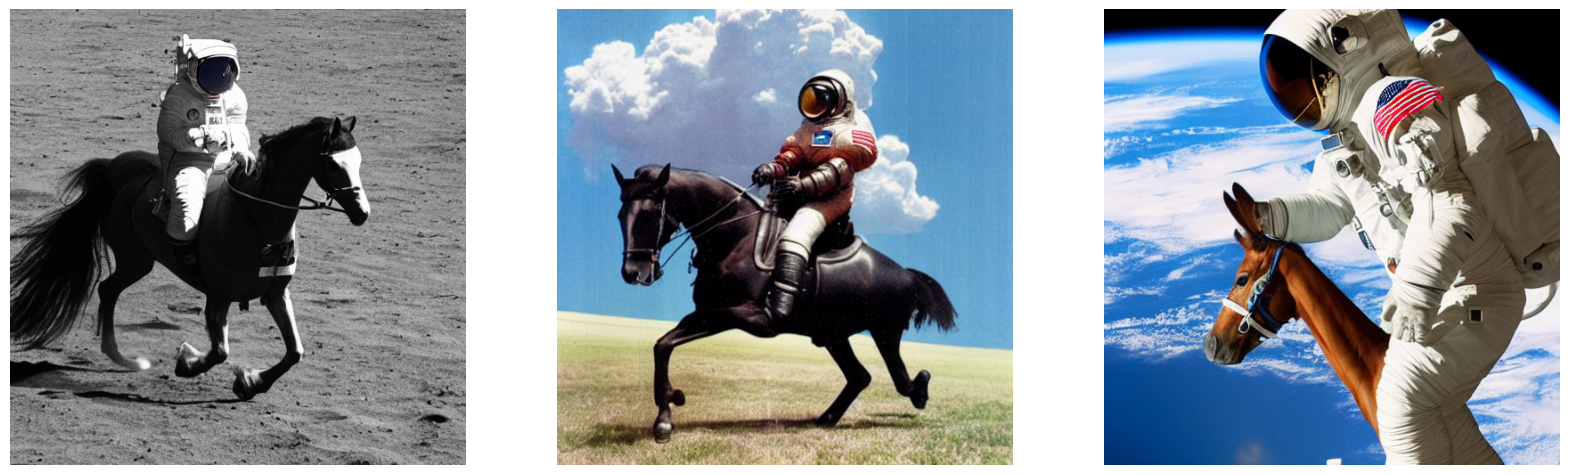

In [ ]:
images = model.text_to_image("photograph of an astronaut riding a horse", batch_size=3)


def plot_images(images):
    plt.figure(figsize=(20, 20))
    for i in range(len(images)):
        ax = plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i])
        plt.axis("off")


plot_images(images)

Не самые лучшие изображения. Но важно понимать, что в библиотеку попадают предыдущие версии моделей (уже устаревшие), а передовые поставляются в виде сервисов, на которых разработчики этих моделей зарабатывают. Причем в сервисах, как правило используется не одна модель, а их цепочка, с предобработкой и постобработкой изображений и промптов!

Обратите внимание, что промты для Stable Diffusion пишутся на английском языке. Как говорится, кто на что учился, а в мире ИИ: кто на чем учился!

А теперь давайте придумаем, что-нибудь красивое и, одновременно, вкусное:

50/50 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step


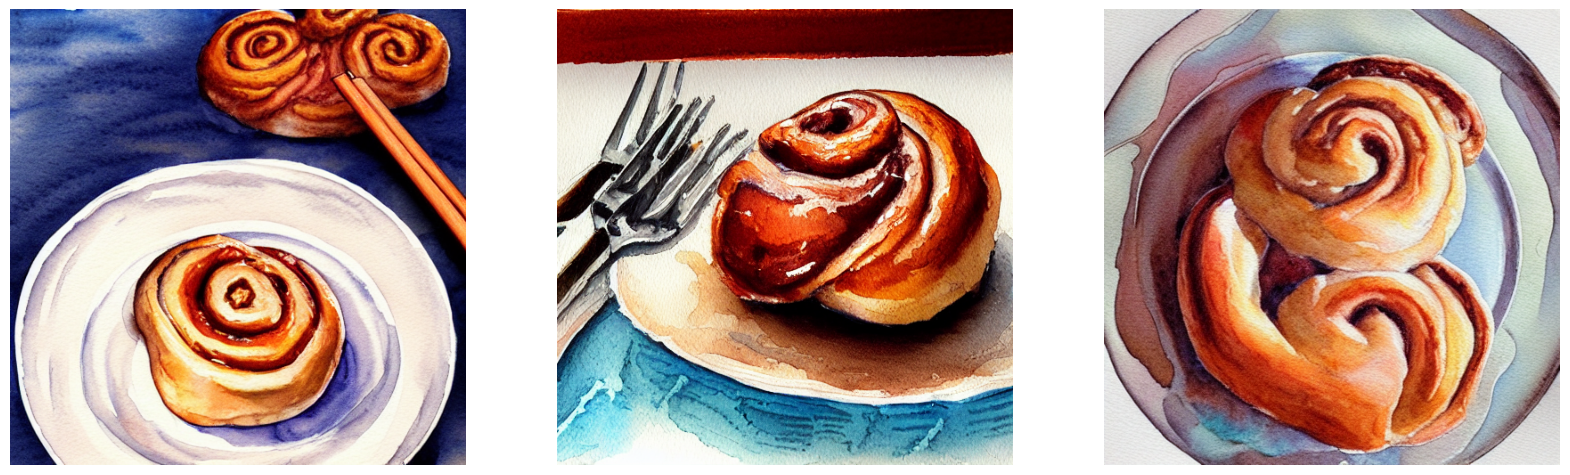

In [ ]:
images = model.text_to_image(
    "cinnamon bun on the plate, watercolor painting, detailed, brush strokes, light palette, light, cozy",
    batch_size=3,
)
plot_images(images)

Получилось не очень аппетитно.

Попробуем сгенерировать стикер:

100/100 ━━━━━━━━━━━━━━━━━━━━ 99s 706ms/step


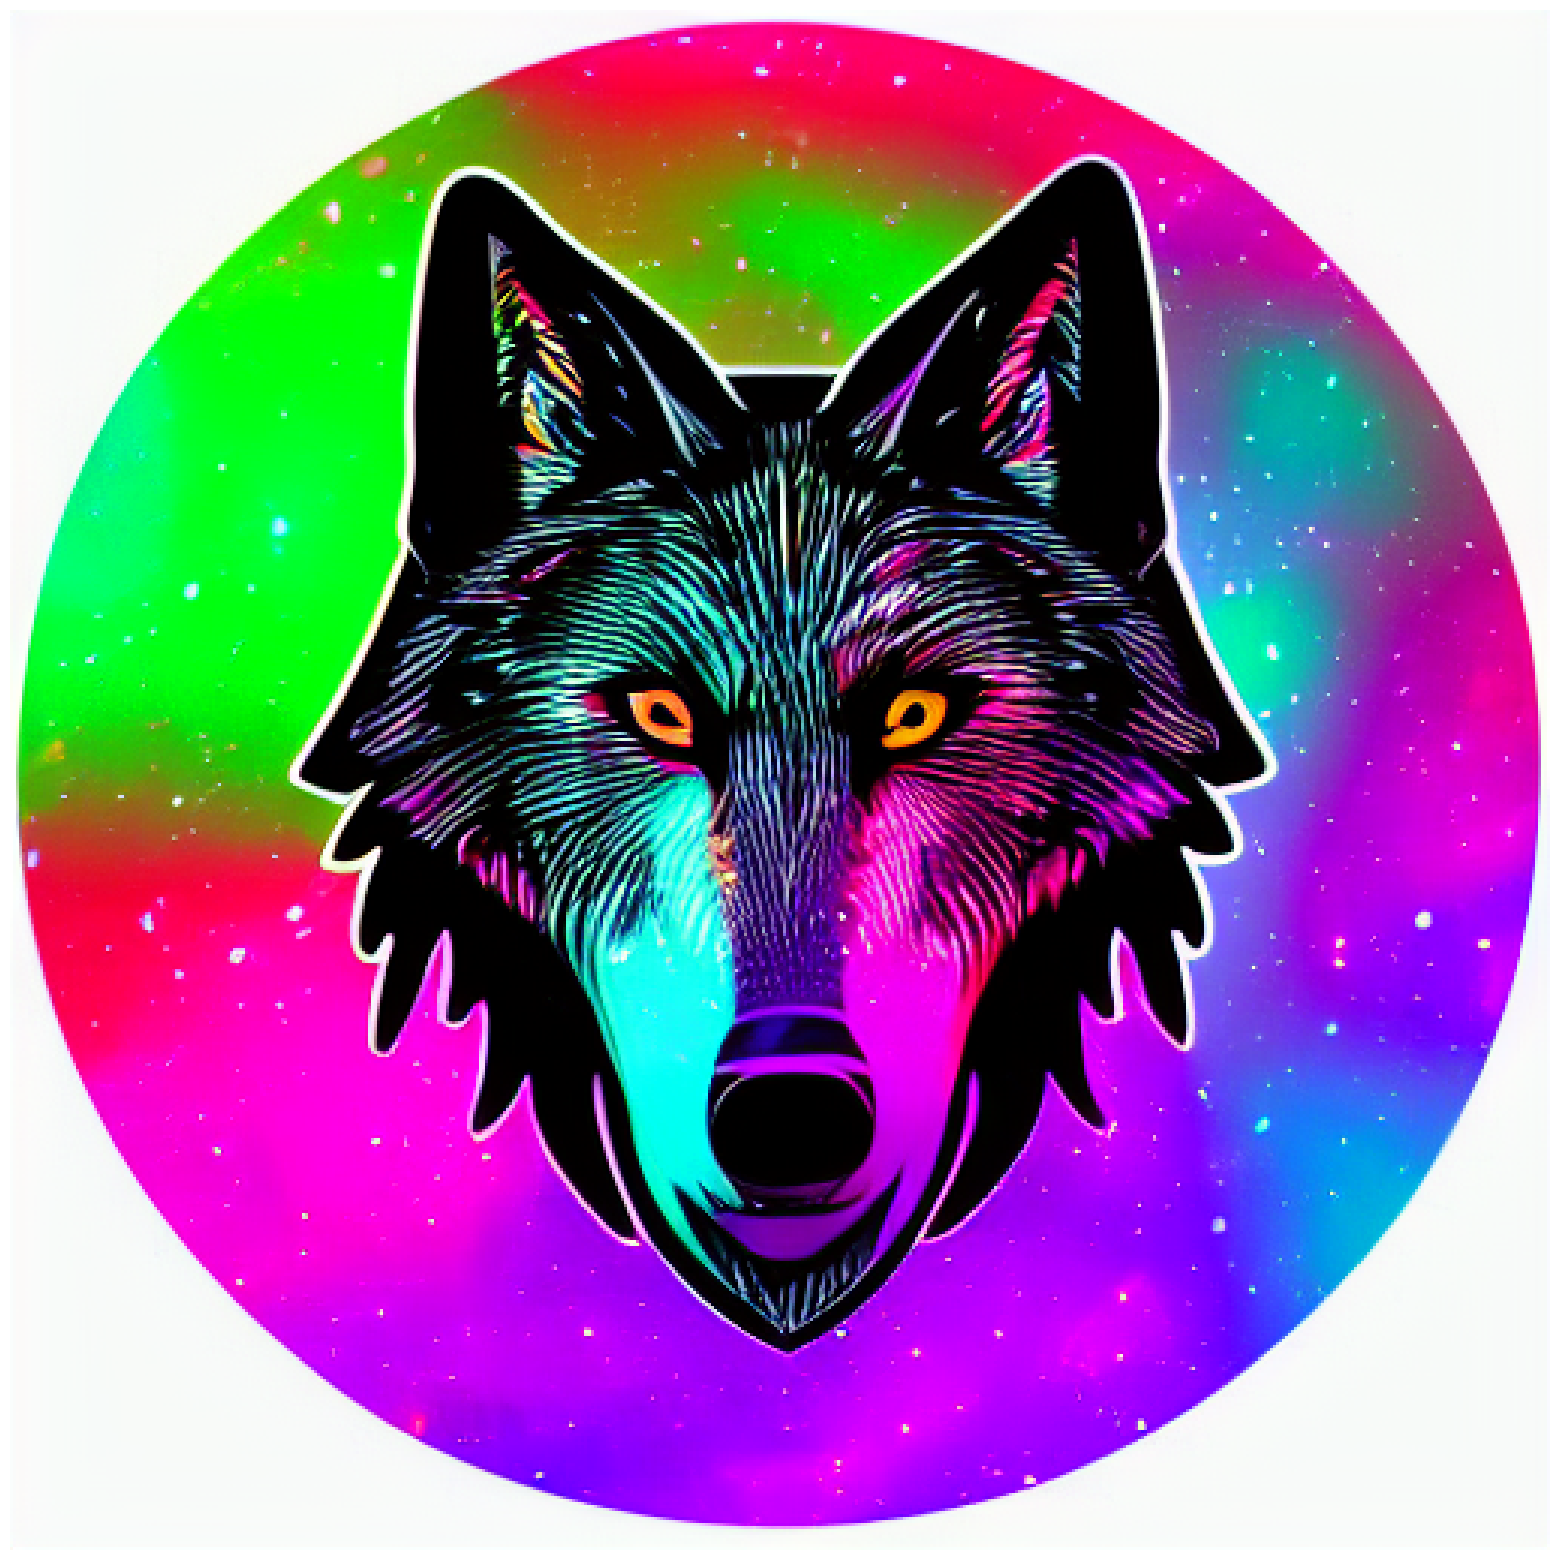

In [ ]:
images = model.text_to_image(
    "vibrant and dynamic die cut sticker design, portraying a wolfs head interlaced with cosmic galaxies, AI, stickers, high contrast, bright neon colors, top-view, high resolution, vector art, detailed stylization, modern graphic art, unique, opaque, weather resistant, UV laminated, white background",
    batch_size=1, # сгенерируем одну картинку
    num_steps=100, # увеличим число шагов "удаления шума" с 50 до 100
)
plot_images(images)

В интернете можно найти большое число промтов для Stable Diffusion (достаточно загуглить: "промты для stable diffusion"). Однако не стоит ожидать 100% совпадения с предлагаемыми примерами. Во-первых, генерация все же вероятностный процесс. Во-вторых, реализаций все же Stable Diffusion множество. Разные библиотеки предлагают свою реализацию.   

### Принципы работы StableDiffusion на пальцах

Все что делает Stable Diffusion - похоже на магию. Но на самом деле здесь нет ничего магического. Просто красивая идея, немного математики и теории вероятности.
В основе лежит принцип сверхвысокого разрешения (super-resolution). Можно обучить модель удалению шума на исходном изображении. Тем самым мы превратим изображение в версию с высоким разрешением. Модель глубокого обучения не может по волшебству «вытащить» утраченную информацию из шума на фото с низким разрешением. Вместо этого она дорисовывает полученные при обучении данные так, чтобы создать иллюзию наиболее вероятных деталей.

Фактически модель обучается на входных изображениях низкого разрешения X на входе, которым сопоставляется изображения высокого разрешения на выходе Y.

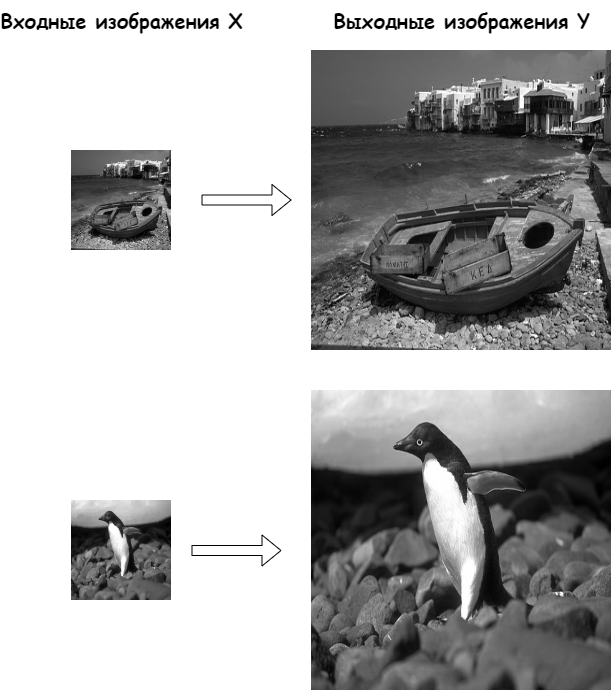

А что если мы пойдем дальше и будем не восстанавливать изображение, а подадим на вход «шум»? Тогда моделе придётся «удалить шум из шума» и создать полностью новое изображение. Повторим это много раз, и маленький фрагмент шума будет превращаться в удивительно чёткое искусственное изображение с высоким разрешением. Фантастика!

Диффузия относится к процессу постепенного превращения структурированного сигнала (изображения) в шум. Моделируя диффузию, мы можем генерировать зашумленные изображения из наших обучающих изображений и можем обучить нейронную сеть пытаться устранить их шум. Используя обученную сеть, мы можем смоделировать противоположность диффузии, обратную диффузию, которая представляет собой процесс формирования изображения из шума.

![diffusion process gif](https://i.imgur.com/dipPOfa.gif)

Поскольку материалы по диффузионным моделям математически довольно сложны и содержат множество теоретических основ (сопоставление оценок, дифференциальные уравнения, цепи Маркова), попытка понять их может оказаться сложной. Поэтому нам сейчас важно понять именно идею, что эти модели учатся разделять зашумленное изображение на составляющие его изображения и гауссовский шум.

О том как построена диффузионная модель, а точнее, как она называется в оригинале - "латентная диффузионная модель", вы можете ознакомиться в оригинальной статье [High-Resolution Image Synthesis with Latent Diffusion Models](https://arxiv.org/pdf/2112.10752.pdf). В статье есть также ссылки и на исходники на [GitHub](https://github.com/CompVis/latent-diffusion).



Для перехода от латентной диффузии к системе создания изображения по текстовому описанию нужно добавить всего одно ключевое свойство: управление генерируемыми изображениями через ключевые слова текстового описания. В этом поможет «стабилизация» (conditioning) — классический метод, который состоит в привязке к фрагменту шума вектора, представляющего собой кусочек текста, а затем обучения модели на наборе данных пар изображений и описаний.

Это даёт начало архитектуре Stable Diffusion (рис. 1), которая состоит из трёх блоков:
* **кодер текста**. Блок преобразует текстовое описание в латентный вектор (latent vector);
* **диффузионная модель**. Многократно удаляет шум с фрагмента изображения 64x64 в латентном состоянии;
* **декодер**. Превращает фрагмент конечного изображения 64x64 в изображение с разрешением 512x512.

Сначала текстовое описание проецируется в скрытое векторное пространство текстовым кодировщиком, который представляет собой просто предварительно обученную, "замороженную" языковую модель. Затем такой вектор подсказок объединяется со случайной сгенерируемым фрагментом шума, который многократно "гасится" (процедура "удаления шума") моделью диффузии в течении множества шагов. Чем больше шагов вы выполняете, тем четче и приятнее будет ваше изображение. По умолчанию таких шагов 50.

Наконец, скрытое изображение 64x64 проходит через декодер, что даёт корректную визуализацию высокого разрешения.

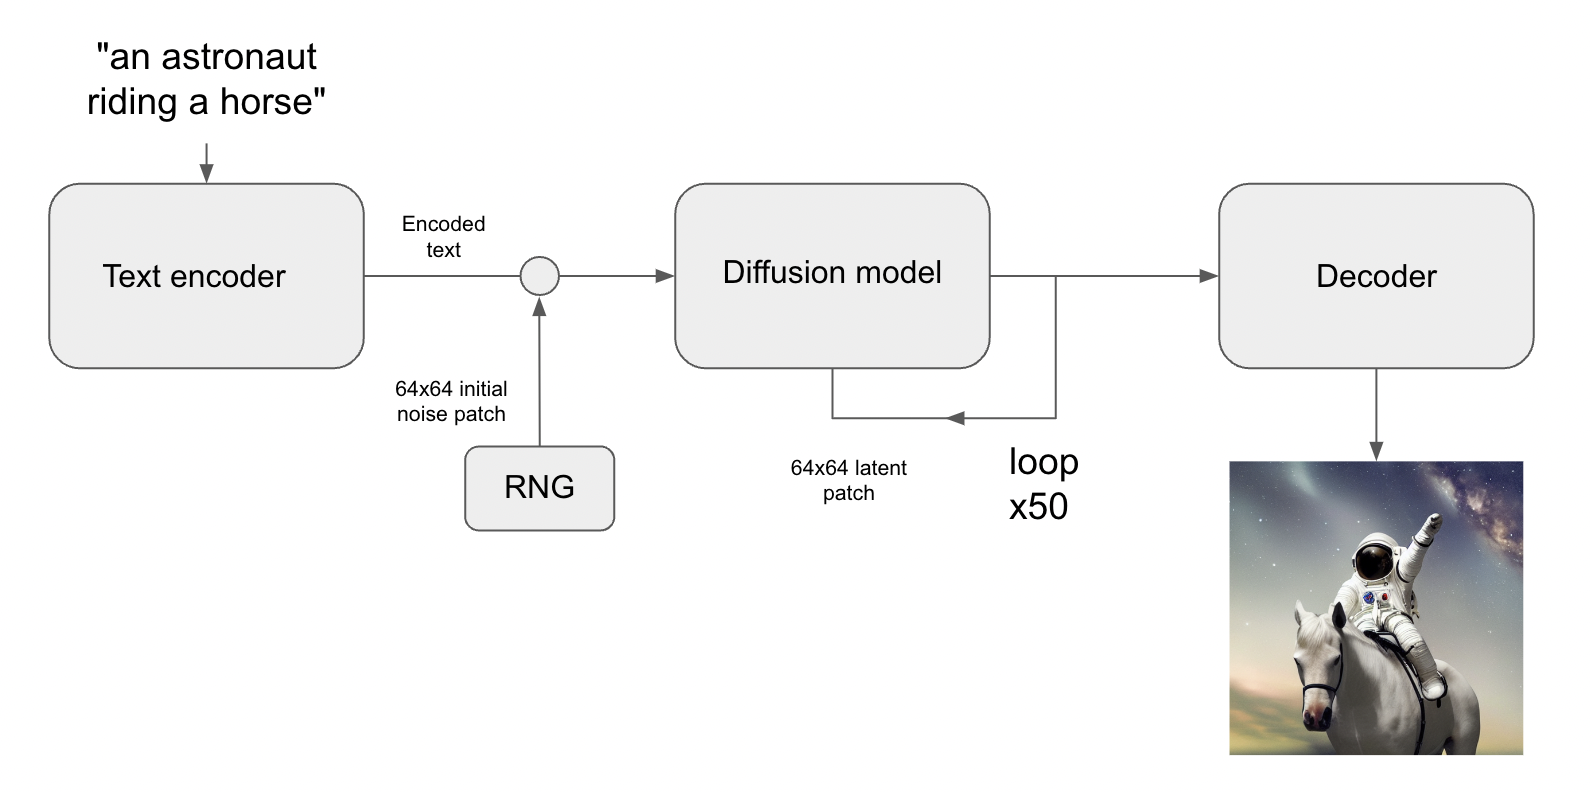

Рис. 1. Архитектура Stable Diffusion

На этом знакомство со Stable Diffusion подощло к концу. Вы можете еще немного погенерировать картинки и переходить к выполнению [домашнего задания](https://colab.research.google.com/drive/1ElbaB78l4c9BbIfHIgBMAzzr0-pBq4QO)